In [1]:
# import necessary modules
# uncomment to get plots displayed in notebook
%matplotlib inline

### import class wrapper

from classy import Class

### math stuff
import numpy as np

### plotting stuff
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d

import tqdm as tqdm

In [2]:
### Plot helpers

plt.rcParams.update({
    "text.usetex": True,                      # Use LaTeX to render all text
    "text.latex.preamble": r"\usepackage{amsmath}", # Load amsmath for advanced math typography
    "font.family": "serif",                   # Use a serif font for the main text
    "font.serif": ["Computer Modern Roman"],  # Match standard LaTeX default font
    "font.size": 14,                          # Standard font size for scientific papers
    "axes.labelsize": 14,                     # Size of the x and y axis labels
    "xtick.labelsize": 12,                     # Size of the x-tick labels
    "ytick.labelsize": 12,                     # Size of the y-tick labels
    "legend.fontsize": 12,                     # Size of the legend text
    "figure.titlesize": 16                    # Size of the figure's main title
})

# colorblind-friendly palette
colors_colorblind = ['#377eb8', '#ff7f00', '#4daf4a',
          '#f781bf', '#a65628', '#984ea3',
          '#999999', '#e41a1c', '#dede00']

In [3]:
# =======================
# BASE COSMOLOGY: Planck 2015 TT,TE,EE+lowE
# =======================
h_fixed     = 0.6727
theta_s_100 = 1.041783
omega_b     = 0.022383
omega_cdm0  = 0.12011
tau_reio    = 0.0543
A_s         = 2.1005829616811546e-9
n_s         = 0.96605

base_params = {
    "theta_s_100": theta_s_100,
    "omega_b": omega_b,
    "omega_cdm": omega_cdm0,
    "A_s": A_s,
    "n_s": n_s,
    "tau_reio": tau_reio,
}

In [4]:
### RUN LCDM for comparison first
lcdm = Class()
lcdm.set(base_params) 
lcdm.set({
    "output": "tCl,pCl,lCl,mPk",
    "l_max_scalars": 2500,
    'lensing': 'yes',
})
lcdm.compute()

### Read background quantities for LCDM

bg_lcdm = lcdm.get_background()
z_lcdm = bg_lcdm['z']
a_lcdm = 1/(1+z_lcdm)
rho_cdm_lcdm = bg_lcdm['(.)rho_cdm']
rho_g_lcdm = bg_lcdm['(.)rho_g']
H_lcdm = bg_lcdm['H [1/Mpc]']
rho_tot_lcdm = bg_lcdm['(.)rho_tot']
z_eq_lcdm = lcdm.get_current_derived_parameters(['z_eq'])
print(f"Redshift of matter-radiation equality in LCDM: {z_eq_lcdm['z_eq']:.2f}")

cl_lcdm = lcdm.lensed_cl(2500)
ll_lcdm = cl_lcdm['ell'][2:]
clTT_lcdm = cl_lcdm['tt'][2:]
clEE_lcdm = cl_lcdm['ee'][2:]
clTE_lcdm = cl_lcdm['te'][2:]


Redshift of matter-radiation equality in LCDM: 3405.82


In [5]:
### SETUP

f_acc = 0.1 # rho_acc/rho_cdm today
kappa = 1
a_t = 0.1

mass = 5e11
eta = 1e11/mass  #0.1

k_values = [1e-3, 1e-2, 1e-1, 1]
k_values_CLASS = ', '.join([str(k) for k in k_values])
ncdm_q_steps = 301
a_rec = 1/(1+1090)

gauge = 'synchronous'
approximations = ['fluid']

### Make a grid of parameters to scan over
a_t_values = [0.01, 0.1, 0.5]
f_acc_values = [0.01, 0.1, 0.5]
eta_values = [0.1, 1, 10]

### Fix f_acc and a_t and scan over all pairs of mass and kappa

mass_values = [1e11, 5e11, 1e12]
eta_values = [1e11/mass for mass in mass_values] # this way we keep the energy of the WDM particle after acceleration fixed at 1e11 GeV, which is a reasonable value below the Planck scale for our purposes
kappa_values = [0.1, 1, 10]

print(eta_values)


[1.0, 0.2, 0.1]


In [6]:
### Run CLASS ###

# Output dictionaries
AccCLASS = {}
bgAcc, pbAcc, clAcc = {}, {}, {}

output_settings = {
        'output': 'tCl, pCl, lCl, mPk',
        'l_max_scalars': 2500,
        'lensing': 'yes',
        'k_output_values': k_values_CLASS
}

bg_settings = {
    'omega_cdm': omega_cdm0*(1+f_acc*(1-a_rec**kappa)/(1+(a_rec/a_t)**kappa))**(-1),
}   

accDM_settings = {
    'vary_Gamma_wdm': 'yes',               # Use the more general formulation
    # 'kappa_mon':      kappa,               # 
    'a_t_mon':        a_t,                 # Scale factor at which the acceleration happens
    'f_wdm':          f_acc,               # Set the fraction of all DM that can be accelerated, i.e. f_acc = rho_acc/(rho_c+rho_acc) in far past. It's a bit weird to set it like this, but eh
    # 'eta_wdm':        eta,                 # Energy gain of the WDM component defined via the enrgy right after acceleration E_wdm = m_wdm(1+\approx)
    "tau_wdm":        1e16,             # REMOVE, Irrelevant in this formulation
    # "m_wdm_in_GeV":   mass,               # accDM mass in GeV
    # "m_cdm_in_GeV":   mass,              # DCDM mass in GeV, in accDM case these two masses should be the same, but this implementation is more general
}

ncdm_settings = {
    # ncdm params [0] is for the neutrinos, [1] is for the WDM component
    "N_ncdm":                   1,                       # accDM is always the last ncdm species, so it has index N_ncdm-1, here we sset N_ncdm=2 to have both massive neutrinos and accDM
    "deg_ncdm":                 1,                  # 3 neutrino species and 1 degrees of freedom for the WDM component 
    "m_ncdm":                   mass*1e9,    # Set a small mass for the neutrino species and a large mass for the WDM component (in eV), the 2nd entry shuld be irrelevant as m_ncdm[1] should be overwritten in the code by m_wdm_in_GeV
    "T_ncdm":                   1,            # Set the same temperature for the WDM component as for the neutrinos,
    "N_ur":                     3.044,                 # Set the number of massless neutrino species to 0 since we are including them as ncdm species
    "ncdm_quadrature_strategy": 4,                  # Quadrature strategy for each ncdm species, 0 (CLASS auto quadrature) for neutrinos, 4 for WDM (logarithmic Simpson, added in CLASS by me based on 2102.12498 -- the repo linked in this paper has WRONG IMPLEMENTATION!)      
    "ncdm_N_momentum_bins" :    ncdm_q_steps, 
    "ncdm_fluid_approximation": 0, # Use fluid approximation for the WDM component if approx=='fluid', otherwise use Boltzmann hierarchy
    "switch_on_eq_delta_p_wdm": 'no', 
    "switch_off_shear_wdm": 'yes', 
}

other_settings = {
    'reionization_z_start_max': 80,      # Default is 50, 80 is the minimal value that works for the chosen values if we set tau_reio to Planck 2018 value, it just widens the bracket so that this doesn't cause issue with shooting for h
    'evolver': 0,
    'gauge': gauge,
    'get_perturbations_in_current_gauge': 'yes',
}

In [ ]:


for kappa in tqdm.tqdm(kappa_values):
    for eta in tqdm.tqdm(eta_values):
        AccCLASS = Class()
        AccCLASS.set(base_params)
        AccCLASS.set(output_settings, **bg_settings, **accDM_settings, **ncdm_settings, **other_settings)
        AccCLASS.set({
            'kappa_mon':      kappa,               
            'm_wdm_in_GeV':   1e11/eta,              
            'm_cdm_in_GeV':   1e11/eta,           
            'eta_wdm':        eta,
        })
        AccCLASS.compute()
        bgAcc[kappa, eta] = AccCLASS.get_background()
        pbAcc[kappa, eta] = AccCLASS.get_perturbations()
        clAcc[kappa, eta] = AccCLASS.lensed_cl(2500)


 67%|██████▋   | 2/3 [01:09<00:34, 34.80s/it]


CosmoComputationError: 

Error in Class: operator()(L:962) :error in perturbations_solve(ppr, pba, pth, ppt, index_md, index_ic, index_k, &pw);
=>perturbations_solve(L:3282) :error in generic_evolver(perturbations_derivs, interval_limit[index_interval], interval_limit[index_interval+1], ppw->pv->y, ppw->pv->used_in_sources, ppw->pv->pt_size, &ppaw, ppr->tol_perturbations_integration, ppr->smallest_allowed_variation, perturbations_timescale, ppr->perturbations_integration_stepsize, ppt->tau_sampling, tau_actual_size, perturbations_sources, perhaps_print_variables, ppt->error_message);
=>evolver_rk(L:110) :error in generic_integrator(derivs, x1, x2, y, parameters_and_workspace_for_derivs, tolerance, x1*minimum_variation, &gi);
=>generic_integrator(L:117) :condition (fabs(hnext/x1) <= hmin) is true; Step size too small: step:7.84082e-13, minimum:1.00962e-12, in interval: [4546.94:4554.23]

In [ ]:
z, a, H = {}, {}, {}
rho_g, rho_cdm, rho_dcdm, rho_b, rho_ur, rho_lambda = {}, {}, {}, {}, {}, {}
rho_acc, p_acc = {}, {}
smooth_rho_acc, smooth_p_acc = {}, {}
rho_nu = {}
rho_tot, rho_crit = {}, {}
z_eq = {}

delta_cdm, delta_g, delta_b, delta_ur, delta_nu = {}, {}, {}, {}, {}
delta_dcdm, delta_acc, delta_dr = {}, {}, {}
rho_plus_p_theta = {}
ll, clTT, clEE, clTE, clPP = {}, {}, {}, {}, {}

phi, phi_prime, psi = {}, {}, {}
h_prime, eta,  eta_prime = {}, {}, {}
delta_rho = {}

CH, CM = {}, {}

for approx in approximations:
    # a, z, and H
    H[approx] = bgAcc[approx]['H [1/Mpc]']
    z[approx] = bgAcc[approx]['z']
    a[approx] = 1/(1+z[approx])
    
    # The usual components of the universe
    rho_g[approx] = bgAcc[approx]['(.)rho_g'] 
    rho_b[approx] = bgAcc[approx]['(.)rho_b']
    rho_cdm[approx] = bgAcc[approx]['(.)rho_cdm']
    rho_lambda[approx] = bgAcc[approx]['(.)rho_lambda']
    rho_ur[approx] = bgAcc[approx]['(.)rho_ur']
    # rho_nu[approx] = bgAcc[approx]['(.)rho_ncdm[0]']

    # Energy densities of the DCDM and WDM components and the pressure of the WDM component
    rho_dcdm[approx] = bgAcc[approx]['(.)rho_dcdm']
    rho_acc[approx] = bgAcc[approx]['(.)rho_ncdm[0]']
    p_acc[approx] = bgAcc[approx]['(.)p_ncdm[0]']

    # Total and critical energy densities
    rho_tot[approx] = bgAcc[approx]['(.)rho_tot']
    rho_crit[approx] = bgAcc[approx]['(.)rho_crit']
    
    z_eq[approx] = AccCLASS.get_current_derived_parameters(['z_eq'])

    for i in range(len(k_values)):
        scalar_data = pbAcc[approx]['scalar'][i]  # Scalar perturbations for selected k-values
        # print(scalar_data.keys())
        a[approx, k_values[i]] = scalar_data['a']
        
        ### Interpolate H onto this a grid
        
        H_interp = interp1d(a[approx], H[approx], kind='cubic', fill_value="extrapolate")
        H[approx, k_values[i]] = H_interp(a[approx, k_values[i]])
    
        # Extract perturbation quantities
        delta_cdm[approx, k_values[i]] = scalar_data['delta_cdm']
        delta_g[approx, k_values[i]] = scalar_data['delta_g']
        delta_b[approx, k_values[i]] = scalar_data['delta_b']
        delta_ur[approx, k_values[i]] = scalar_data['delta_ur']
        # delta_nu[approx, k_values[i]] = scalar_data['delta_ncdm[0]']
        
        delta_dcdm[approx, k_values[i]] = scalar_data['delta_dcdm']
        delta_acc[approx, k_values[i]] = scalar_data['delta_ncdm[0]']
        delta_rho[approx, k_values[i]] = scalar_data['delta_rho_tot'] # For testing
        if gauge == 'synchronous':
            eta[approx, k_values[i]] = scalar_data['eta'] # For testing
            h_prime[approx, k_values[i]] = scalar_data['h_prime']
            eta_prime[approx, k_values[i]] = scalar_data['eta_prime']  
            rho_plus_p_theta[approx, k_values[i]] = scalar_data['rho_plus_p_theta'] # For testing
            CH[approx, k_values[i]] = k_values[i]**2*eta[approx, k_values[i]]+0.5*a[approx, k_values[i]]*H[approx, k_values[i]]*h_prime[approx, k_values[i]]+1.5*a[approx, k_values[i]]**2*delta_rho[approx, k_values[i]]
            CM[approx, k_values[i]] = k_values[i]**2*eta_prime[approx, k_values[i]]-3*a[approx, k_values[i]]**2/2*rho_plus_p_theta[approx, k_values[i]]
        else:
            phi[approx, k_values[i]] = scalar_data['phi']
            phi_prime[approx, k_values[i]] = scalar_data['phi_prime']
            psi[approx, k_values[i]] = scalar_data['psi']
            CM[approx, k_values[i]] = -k_values[i]**2*(phi_prime[approx, k_values[i]]+H[approx, k_values[i]]*psi[approx, k_values[i]]); #4piGa^2(rho_plus_p)delta... 
        ### POWER SPECTRUM
        
    ll[approx] = clAcc[approx]['ell'][2:]
    clTT[approx] = clAcc[approx]['tt'][2:]
    clEE[approx] = clAcc[approx]['ee'][2:]
    clTE[approx] = clAcc[approx]['te'][2:]
    clPP[approx] = clAcc[approx]['pp'][2:]

In [12]:
import os, time
import pandas as pd

# --- scan grid ---
kappa_values = np.array([0.25, 0.5, 1.0, 2.0, 4.0, 8.0, 10.0, 12.0])
mass_values  = np.logspace(11, 18, 10)        # GeV. eta := 1e11/mass; mass*(1+eta) < 1e19

a_t_scan    = 0.1
f_acc_scan  = 0.1
approx_scan = 'fluid'

checkpoint_path = 'fluid_approx_scan_results.csv'

# Lighter output for failure-detection scans; uncomment full block for spectra.
output_settings_scan = {'output': 'mPk'}
# output_settings_scan = {
#     'output': 'tCl, pCl, lCl, mPk',
#     'l_max_scalars': 2500,
#     'lensing': 'yes',
# }

# --- resume from checkpoint if it exists ---
if os.path.exists(checkpoint_path):
    df_done = pd.read_csv(checkpoint_path)
    done = set(zip(df_done['kappa'].round(8), df_done['mass'].round(0)))
    print(f"Resuming: {len(done)} points already on disk")
else:
    done = set()

points = [(float(k), float(m)) for k in kappa_values for m in mass_values
          if (round(float(k), 8), round(float(m), 0)) not in done]
print(f"Running {len(points)} new points")

def append_row(row):
    pd.DataFrame([row]).to_csv(
        checkpoint_path, mode='a',
        header=not os.path.exists(checkpoint_path),
        index=False,
    )

for kk, mm in tqdm.tqdm(points):
    ee = 1e11 / mm                            # eta tied to mass
    row = {'kappa': kk, 'mass': mm, 'eta': ee, 'a_t': a_t_scan,
           'status': None, 'error': '', 'runtime_s': np.nan, 'sigma8': np.nan}

    # --- pre-screen: post-acceleration energy at/above Planck ---
    if mm * (1 + ee) >= 1e19:
        row['status'] = 'skipped_planck'
        row['error']  = 'energy above Planck'
        append_row(row); continue

    M = None
    t0 = time.time()
    try:
        bg_settings_loop = {
            'omega_cdm': omega_cdm0 *
                (1 + f_acc_scan*(1 - a_rec**kk)/(1 + (a_rec/a_t_scan)**kk))**(-1),
        }
        accDM_loop = dict(accDM_settings,
                          kappa_mon=kk, a_t_mon=a_t_scan,
                          eta_wdm=ee, f_wdm=f_acc_scan,
                          m_wdm_in_GeV=mm, m_cdm_in_GeV=mm)
        ncdm_loop  = dict(ncdm_settings, m_ncdm=mm*1e9)

        M = Class()
        M.set(base_params)
        M.set(output_settings_scan, **bg_settings_loop,
              **accDM_loop, **ncdm_loop, **other_settings)
        M.compute()

        row['status'] = 'ok'
        try: row['sigma8'] = M.sigma8()
        except Exception: pass

    except Exception as e:
        name = type(e).__name__
        if   'Severe'      in name: row['status'] = 'severe_error'
        elif 'Computation' in name: row['status'] = 'compute_error'
        else:                       row['status'] = 'exception'
        row['error'] = f"{name}: {str(e).strip().splitlines()[-1]}"[:300]

    finally:
        row['runtime_s'] = time.time() - t0
        if M is not None:
            try: M.struct_cleanup()
            except Exception: pass
            try: M.empty()
            except Exception: pass
            del M

    append_row(row)

df_scan = pd.read_csv(checkpoint_path)
print("\nStatus counts:")
print(df_scan['status'].value_counts())
df_scan


Resuming: 1 points already on disk
Running 79 new points


100%|██████████| 79/79 [05:06<00:00,  3.88s/it]


Status counts:
status
ok               41
compute_error    39
Name: count, dtype: int64


,kappa,mass,eta,a_t,status,error,runtime_s,sigma8
0,0.25,1.000000e+11,1.000000e+00,0.1,ok,NaN,9.410967,0.626167
1,0.25,5.994843e+11,1.668101e-01,0.1,ok,NaN,4.066149,0.644832
2,0.25,3.593814e+12,2.782559e-02,0.1,ok,NaN,4.349867,0.657989
3,0.25,2.154435e+13,4.641589e-03,0.1,ok,NaN,4.415587,0.688457
4,0.25,1.291550e+14,7.742637e-04,0.1,ok,NaN,3.182063,0.734889
...,...,...,...,...,...,...,...,...
75,12.00,7.742637e+14,1.291550e-04,0.1,compute_error,CosmoComputationError: =>generic_integrator(L:...,3.837530,NaN
76,12.00,4.641589e+15,2.154435e-05,0.1,compute_error,CosmoComputationError: =>generic_integrator(L:...,2.779463,NaN
77,12.00,2.782559e+16,3.593814e-06,0.1,compute_error,CosmoComputationError: =>generic_integrator(L:...,3.935420,NaN
78,12.00,1.668101e+17,5.994843e-07,0.1,compute_error,CosmoComputationError: =>generic_integrator(L:...,3.810760,NaN


Index([0.25, 0.5, 1.0, 2.0, 4.0, 8.0, 10.0, 12.0], dtype='float64', name='kappa')


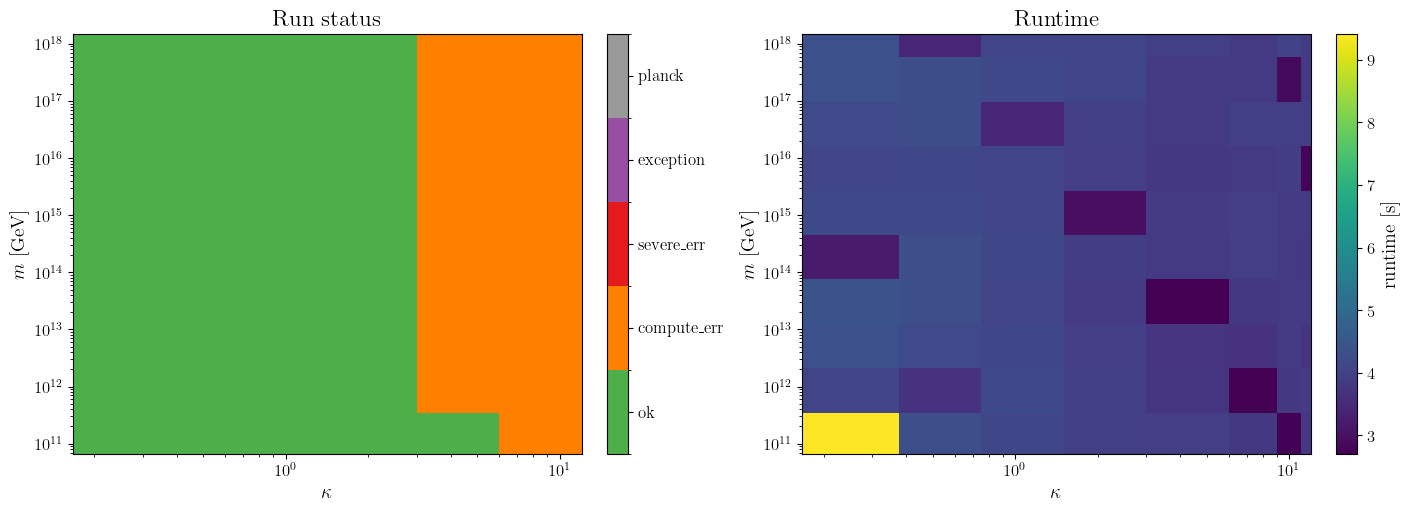


39 bad points:
 kappa         mass          eta        status                                                                                                                                                                                      error
   4.0 5.994843e+11 1.668101e-01 compute_error CosmoComputationError: =>generic_integrator(L:117) :condition (fabs(hnext/x1) <= hmin) is true; Step size too small: step:9.91568e-14, minimum:1.46022e-13, in interval: [657.625:667.742]
   4.0 3.593814e+12 2.782559e-02 compute_error CosmoComputationError: =>generic_integrator(L:117) :condition (fabs(hnext/x1) <= hmin) is true; Step size too small: step:4.75462e-14, minimum:1.33658e-13, in interval: [601.941:611.649]
   4.0 2.154435e+13 4.641589e-03 compute_error CosmoComputationError: =>generic_integrator(L:117) :condition (fabs(hnext/x1) <= hmin) is true; Step size too small: step:6.43295e-14, minimum:8.00994e-14, in interval: [360.736:366.462]
   4.0 1.291550e+14 7.742637e-04 compute_error  

In [19]:
from matplotlib.colors import ListedColormap, BoundaryNorm

status_map = {'ok': 0, 'compute_error': 1, 'severe_error': 2,
              'exception': 3, 'skipped_planck': 4}
df_scan['status_code'] = df_scan['status'].map(status_map)

g_status  = df_scan.pivot(index='mass', columns='kappa', values='status_code').sort_index().sort_index(axis=1)
g_runtime = df_scan.pivot(index='mass', columns='kappa', values='runtime_s' ).sort_index().sort_index(axis=1)

print(g_status.columns)

cmap = ListedColormap(['#4daf4a', '#ff7f00', '#e41a1c', '#984ea3', '#999999'])
norm = BoundaryNorm(np.arange(-0.5, 5.5, 1), cmap.N)

fig, axs = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

im0 = axs[0].pcolormesh(g_status.columns, g_status.index, g_status.values,
                        cmap=cmap, norm=norm, shading='nearest')
cb = fig.colorbar(im0, ax=axs[0], ticks=range(5))
cb.ax.set_yticklabels(['ok','compute_err','severe_err','exception','planck'])
axs[0].set_xscale('log'); axs[0].set_yscale('log')
axs[0].set_xlabel(r'$\kappa$'); axs[0].set_ylabel(r'$m$ [GeV]')
axs[0].set_title('Run status')
axs[0].set_xlim(g_status.columns.min()/1.5, g_status.columns.max())
axs[0].set_ylim(g_status.index.min()/1.5, g_status.index.max()*1.5)

im1 = axs[1].pcolormesh(g_runtime.columns, g_runtime.index, g_runtime.values,
                        cmap='viridis', shading='nearest')
fig.colorbar(im1, ax=axs[1], label='runtime [s]')
axs[1].set_xscale('log'); axs[1].set_yscale('log')
axs[1].set_xlim(g_status.columns.min()/1.5, g_status.columns.max())
axs[1].set_ylim(g_status.index.min()/1.5, g_status.index.max()*1.5)
axs[1].set_xlabel(r'$\kappa$'); axs[1].set_ylabel(r'$m$ [GeV]')
axs[1].set_title('Runtime')
plt.show()

bad = df_scan[df_scan['status'] != 'ok'][['kappa','mass','eta','status','error']]
print(f"\n{len(bad)} bad points:")
print(bad.to_string(index=False))
